# CrowdStrike Pilot — Reddit Audience Response to Corporate Apology

Project（Apology Under Scrutiny）:
 Reddit Audience Response to Corporate Apologies Across Competence and Integrity Crises**Author:** Eva Hu — MACS 30200, University of Chicago, Spring 2026**Repo:** https://github.com/EvaHu0/apology-under-scrutinyThis notebook runs the proof-of-concept pipeline on **real Reddit data** for the CrowdStrike case (competence-based crisis, 2024-07-19).**Pipeline:** PullPush.io collection → preprocessing (SHA-256 hash usernames) → VADER + Twitter-RoBERTa sentiment → LDA topic modeling → pre/post apology comparison.**Before running:** `Runtime → Change runtime type → T4 GPU` (free tier is fine).Then `Runtime → Run all`. Total runtime ~5–10 minutes.

## 1. Setup

In [1]:
!pip install -q vaderSentiment transformers torch accelerate gensim nltk scipy

import nltk
for pkg in ['vader_lexicon', 'stopwords', 'wordnet', 'punkt', 'punkt_tab', 'omw-1.4']:
    nltk.download(pkg, quiet=True)
print("Setup OK")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 46.5 MB/s eta 0:00:00
Setup OK


In [2]:
import requests, time, json, hashlib, re, os
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Reproducibility
np.random.seed(42)

# Case constants — CrowdStrike, July 2024
CASE = "CrowdStrike"
T_CRISIS  = int(datetime(2024, 7, 19,  4,  9, 0, tzinfo=timezone.utc).timestamp())   # initial public reports
T_APOLOGY = int(datetime(2024, 7, 19, 15, 45, 0, tzinfo=timezone.utc).timestamp())   # Kurtz first apology
T_AFTER   = T_CRISIS  - 24 * 3600        # 1 day before crisis
T_BEFORE  = T_APOLOGY + 30 * 24 * 3600   # 30 days after apology

SUBREDDITS = ['technology', 'sysadmin', 'news']
QUERY = "CrowdStrike"
TARGET_N = 1500

print(f"Case: {CASE}")
print(f"Crisis:   {datetime.fromtimestamp(T_CRISIS, tz=timezone.utc)}")
print(f"Apology:  {datetime.fromtimestamp(T_APOLOGY, tz=timezone.utc)}")
print(f"Window:   {datetime.fromtimestamp(T_AFTER, tz=timezone.utc)}")
print(f"     to:  {datetime.fromtimestamp(T_BEFORE, tz=timezone.utc)}")
print(f"Subreddits: {SUBREDDITS}")

Case: CrowdStrike
Crisis:   2024-07-19 04:09:00+00:00
Apology:  2024-07-19 15:45:00+00:00
Window:   2024-07-18 04:09:00+00:00
     to:  2024-08-18 15:45:00+00:00
Subreddits: ['technology', 'sysadmin', 'news']


## 2. Data collection (PullPush.io)Paginates backwards through time using the `before` parameter. Polite half-second sleeps between calls.

In [3]:
def fetch_pullpush(subreddit, after, before, query, size=100, max_pages=15):
    """Fetch comments from r/<subreddit> matching `query` between `after` and `before` UTC."""
    base = "https://api.pullpush.io/reddit/search/comment/"
    comments = []
    current_before = before
    for page in range(max_pages):
        params = {
            'subreddit': subreddit,
            'q': query,
            'after': after,
            'before': current_before,
            'size': size,
            'sort': 'desc',
            'sort_type': 'created_utc',
        }
        try:
            r = requests.get(base, params=params, timeout=30)
            if r.status_code != 200:
                print(f"  page {page}: HTTP {r.status_code} — stopping")
                break
            data = r.json().get('data', [])
        except Exception as e:
            print(f"  page {page}: error {e}")
            break
        if not data:
            print(f"  page {page}: no more data")
            break
        comments.extend(data)
        # advance backwards: next batch must be older than the oldest we just saw
        oldest = min(c['created_utc'] for c in data)
        if oldest >= current_before:
            print(f"  page {page}: pagination stuck — stopping")
            break
        current_before = oldest - 1
        print(f"  page {page}: +{len(data):>3} comments  (running total {len(comments)})")
        time.sleep(0.5)
    return comments

all_raw = []
for sub in SUBREDDITS:
    print(f"\nFetching r/{sub}…")
    raw = fetch_pullpush(sub, T_AFTER, T_BEFORE, QUERY)
    all_raw.extend(raw)
    print(f"r/{sub} done: {len(raw)} comments")

print(f"\n=== TOTAL RAW: {len(all_raw)} comments ===")

if len(all_raw) == 0:
    print("\n!!! PullPush returned 0 comments. Possible causes:")
    print("    1. PullPush.io is down — try again in a few minutes")
    print("    2. Rate limited — sleep longer between calls")
    print("    3. Need Arctic Shift fallback — message Claude")


Fetching r/technology…
  page 0: +100 comments  (running total 100)
  page 1: +100 comments  (running total 200)
  page 2: +100 comments  (running total 300)
  page 3: +100 comments  (running total 400)
  page 4: +100 comments  (running total 500)
  page 5: +100 comments  (running total 600)
  page 6: +100 comments  (running total 700)
  page 7: +100 comments  (running total 800)
  page 8: +100 comments  (running total 900)
  page 9: +100 comments  (running total 1000)
  page 10: +100 comments  (running total 1100)
  page 11: +100 comments  (running total 1200)
  page 12: +100 comments  (running total 1300)
  page 13: +100 comments  (running total 1400)
  page 14: +100 comments  (running total 1500)
r/technology done: 1500 comments

Fetching r/sysadmin…
  page 0: +100 comments  (running total 100)
  page 1: +100 comments  (running total 200)
  page 2: +100 comments  (running total 300)
  page 3: +100 comments  (running total 400)
  page 4: +100 comments  (running total 500)
  page 5: 

## 3. Preprocessing- Drop `[deleted]` / `[removed]` / empty bodies- Drop comments shorter than 3 tokens- Drop AutoModerator and known bots- SHA-256 hash usernames (first 16 hex chars)- Drop duplicate IDs

In [4]:
def sha256_hash(s, length=16):
    return hashlib.sha256(s.encode('utf-8')).hexdigest()[:length]

BOT_AUTHORS = {'AutoModerator', '[deleted]', 'sneakpeekbot', 'WikiTextBot', 'RemindMeBot'}

records = []
for c in all_raw:
    body = c.get('body', '') or ''
    if body in ('[deleted]', '[removed]', ''):
        continue
    if len(body.split()) < 3:
        continue
    author = c.get('author') or 'unknown'
    if author in BOT_AUTHORS:
        continue
    created = c.get('created_utc')
    if created is None:
        continue
    records.append({
        'id':          c.get('id'),
        'parent_id':   c.get('parent_id'),
        'link_id':     c.get('link_id'),
        'subreddit':   c.get('subreddit'),
        'author_hash': sha256_hash(author),
        'score':       c.get('score', 0),
        'created_utc': int(created),
        'body':        body,
        'window':      'pre' if int(created) < T_APOLOGY else 'post',
    })

df = pd.DataFrame(records).drop_duplicates(subset=['id']).reset_index(drop=True)
print(f"After filtering: {len(df)} comments")
print("\nBy subreddit:")
print(df['subreddit'].value_counts())
print("\nBy pre/post window:")
print(df['window'].value_counts())
print("\nScore distribution:")
print(df['score'].describe())

After filtering: 3768 comments

By subreddit:
subreddit
sysadmin      1473
technology    1457
news           838
Name: count, dtype: int64

By pre/post window:
window
post    3389
pre      379
Name: count, dtype: int64

Score distribution:
count    3768.000000
mean        1.133758
std         4.535164
min        -5.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       261.000000
Name: score, dtype: float64


## 4. VADER sentiment (lexicon baseline)Maps compound score to label:- `> 0.05` → positive- `< -0.05` → negative- otherwise → neutral

In [5]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

df['vader'] = df['body'].apply(lambda t: sia.polarity_scores(t)['compound'])

def vader_label(s):
    if s >=  0.05: return 'positive'
    if s <= -0.05: return 'negative'
    return 'neutral'

df['vader_label'] = df['vader'].apply(vader_label)

print("VADER summary by window:")
print(df.groupby('window')['vader'].describe()[['count','mean','std','min','max']])
print("\nVADER label distribution:")
print(df.groupby(['window','vader_label']).size().unstack(fill_value=0))

VADER summary by window:
         count      mean       std     min     max
window                                            
post    3389.0  0.004294  0.554727 -0.9948  0.9952
pre      379.0 -0.052261  0.460902 -0.9962  0.8845

VADER label distribution:
vader_label  negative  neutral  positive
window                                  
post             1406      548      1435
pre               165       93       121


## 5. Twitter-RoBERTa sentiment (transformer)Uses `cardiffnlp/twitter-roberta-base-sentiment-latest`. Will use GPU if available.

In [6]:
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1
print(f"Device: {'GPU' if device == 0 else 'CPU'}")
if device == -1:
    print("WARNING: no GPU detected. RoBERTa will be slow.")
    print("Fix: Runtime → Change runtime type → T4 GPU, then Runtime → Restart and run all")

clf = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    device=device,
    truncation=True,
    max_length=512,
)

print("Running RoBERTa…")
t0 = time.time()
results = clf(df['body'].tolist(), batch_size=32)
print(f"Done in {time.time()-t0:.1f}s")

df['roberta_label'] = [r['label'] for r in results]
df['roberta_score'] = [r['score'] for r in results]

# signed score for t-test
def signed(row):
    if row['roberta_label'] == 'positive': return  row['roberta_score']
    if row['roberta_label'] == 'negative': return -row['roberta_score']
    return 0.0
df['roberta_signed'] = df.apply(signed, axis=1)

print("\nRoBERTa label distribution by window:")
print(df.groupby(['window','roberta_label']).size().unstack(fill_value=0))

Device: GPU


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Running RoBERTa…
Done in 63.6s

RoBERTa label distribution by window:
roberta_label  negative  neutral  positive
window                                    
post               1909     1277       203
pre                 229      132        18


## 6. VADER vs RoBERTa agreementSanity check: how often do the two models agree? Disagreements are where lexicon-based sentiment likely fails (sarcasm, irony, domain-specific phrasing).

In [7]:
df['agree'] = df['vader_label'] == df['roberta_label']
agreement_rate = df['agree'].mean()
print(f"Overall VADER–RoBERTa agreement: {agreement_rate:.1%}")

# Confusion matrix (proportions of all comments)
ct = pd.crosstab(df['vader_label'], df['roberta_label'])
print("\nConfusion matrix (counts):")
print(ct)
print("\nNormalized by VADER label (rows):")
print(pd.crosstab(df['vader_label'], df['roberta_label'], normalize='index').round(3))

Overall VADER–RoBERTa agreement: 46.9%

Confusion matrix (counts):
roberta_label  negative  neutral  positive
vader_label                               
negative           1210      347        14
neutral             274      359         8
positive            654      703       199

Normalized by VADER label (rows):
roberta_label  negative  neutral  positive
vader_label                               
negative          0.770    0.221     0.009
neutral           0.427    0.560     0.012
positive          0.420    0.452     0.128


## 7. LDA topic modelingSelect k from {4,5,6,7,8} by c_v coherence. Use the selected k for final model and per-document topic distribution.

In [8]:
from gensim import corpora, models
from gensim.models.coherencemodel import CoherenceModel
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words('english'))
# case-specific filler / ubiquitous terms
stop_words.update(['like', 'would', 'could', 'one', 'get', 'also', 'really', 'even',
                   'crowdstrike', 'falcon'])
lem = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    tokens = text.split()
    return [lem.lemmatize(t) for t in tokens if t not in stop_words and len(t) > 2]

df['tokens'] = df['body'].apply(preprocess)
texts = df['tokens'].tolist()
texts = [t for t in texts if len(t) >= 3]   # drop empty/tiny token lists

print(f"Documents for LDA: {len(texts)}")

dictionary = corpora.Dictionary(texts)
dictionary.filter_extremes(no_below=5, no_above=0.5)
corpus = [dictionary.doc2bow(t) for t in texts]

print(f"Vocabulary size: {len(dictionary)}")

print("\nSelecting k via c_v coherence:")
coh_scores = {}
for k in [4, 5, 6, 7, 8]:
    lda = models.LdaModel(corpus, num_topics=k, id2word=dictionary,
                          passes=10, random_state=42, alpha='auto')
    cm = CoherenceModel(model=lda, texts=texts, dictionary=dictionary, coherence='c_v')
    coh_scores[k] = cm.get_coherence()
    print(f"  k={k}: coherence={coh_scores[k]:.3f}")

best_k = max(coh_scores, key=coh_scores.get)
print(f"\nSelected k = {best_k}")

# refit final model with more passes
lda = models.LdaModel(corpus, num_topics=best_k, id2word=dictionary,
                      passes=20, random_state=42, alpha='auto')

print(f"\nTopics:")
for tid in range(best_k):
    words = lda.show_topic(tid, topn=10)
    print(f"  T{tid}: {', '.join(w for w,p in words)}")

Documents for LDA: 3581
Vocabulary size: 2643

Selecting k via c_v coherence:
  k=4: coherence=0.434
  k=5: coherence=0.404
  k=6: coherence=0.487
  k=7: coherence=0.453
  k=8: coherence=0.446

Selected k = 6

Topics:
  T0: update, testing, software, system, test, driver, file, window, kernel, process
  T1: window, server, file, system, recovery, key, boot, fix, running, safe
  T2: thing, outage, company, way, time, work, never, good, week, people
  T3: microsoft, kernel, window, software, system, access, linux, issue, security, party
  T4: company, people, time, day, issue, going, year, work, ceo, still
  T5: company, delta, use, microsoft, product, insurance, damage, going, much, contract


## 8. Topic prevalence by pre/post window

In [9]:
# For each document, get full topic distribution
def doc_topic_dist(bow):
    return {tid: p for tid, p in lda.get_document_topics(bow, minimum_probability=0)}

# Align corpus back to df (we filtered some)
df_lda = df.copy()
df_lda['tokens_ok'] = df_lda['tokens'].apply(lambda t: len(t) >= 3)
df_for_topics = df_lda[df_lda['tokens_ok']].reset_index(drop=True)
assert len(df_for_topics) == len(corpus), f"{len(df_for_topics)} vs {len(corpus)}"

topic_dists = [doc_topic_dist(b) for b in corpus]
for tid in range(best_k):
    df_for_topics[f'topic_{tid}'] = [d.get(tid, 0) for d in topic_dists]

topic_cols = [f'topic_{t}' for t in range(best_k)]
prevalence = df_for_topics.groupby('window')[topic_cols].mean()
print("Mean topic prevalence by window:")
print(prevalence.round(3))

Mean topic prevalence by window:
        topic_0  topic_1  topic_2  topic_3  topic_4  topic_5
window                                                      
post      0.170    0.097    0.158    0.123    0.304    0.147
pre       0.158    0.148    0.163    0.131    0.303    0.098


## 9. Statistical tests (pre vs post)

In [10]:
pre_v  = df[df['window']=='pre']['vader'].values
post_v = df[df['window']=='post']['vader'].values
t_v, p_v = stats.ttest_ind(pre_v, post_v, equal_var=False)

pre_r  = df[df['window']=='pre']['roberta_signed'].values
post_r = df[df['window']=='post']['roberta_signed'].values
t_r, p_r = stats.ttest_ind(pre_r, post_r, equal_var=False)

print("=== SENTIMENT: pre vs post apology ===\n")
print(f"VADER:")
print(f"  pre  μ = {pre_v.mean():+.3f}  (n = {len(pre_v):>4})")
print(f"  post μ = {post_v.mean():+.3f}  (n = {len(post_v):>4})")
print(f"  Welch's t = {t_v:.3f},  p = {p_v:.2e}")
print(f"  shift = {(post_v.mean() - pre_v.mean()):+.3f} compound units")
print()
print(f"RoBERTa:")
print(f"  pre  μ = {pre_r.mean():+.3f}  (n = {len(pre_r):>4})")
print(f"  post μ = {post_r.mean():+.3f}  (n = {len(post_r):>4})")
print(f"  Welch's t = {t_r:.3f},  p = {p_r:.2e}")
print(f"  shift = {(post_r.mean() - pre_r.mean()):+.3f} signed-score units")

=== SENTIMENT: pre vs post apology ===

VADER:
  pre  μ = -0.052  (n =  379)
  post μ = +0.004  (n = 3389)
  Welch's t = -2.216,  p = 2.71e-02
  shift = +0.057 compound units

RoBERTa:
  pre  μ = -0.440  (n =  379)
  post μ = -0.368  (n = 3389)
  Welch's t = -2.904,  p = 3.86e-03
  shift = +0.072 signed-score units


## 10. FiguresSaves four PNGs to `/content/`. Download them after running.

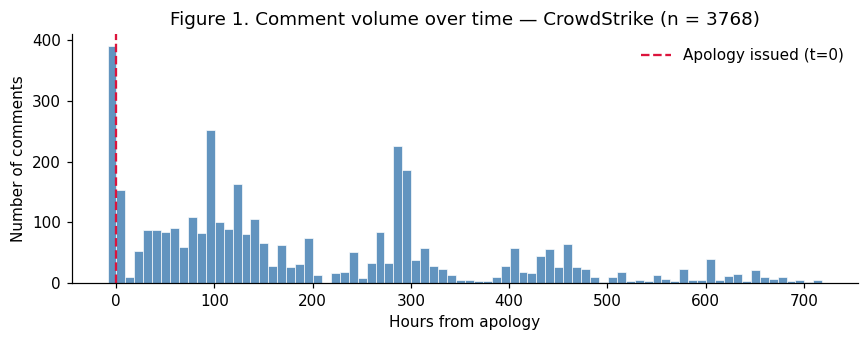

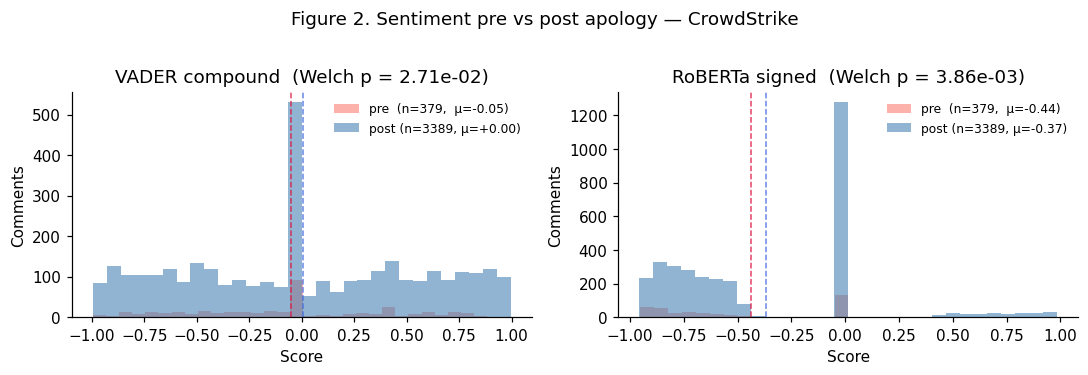

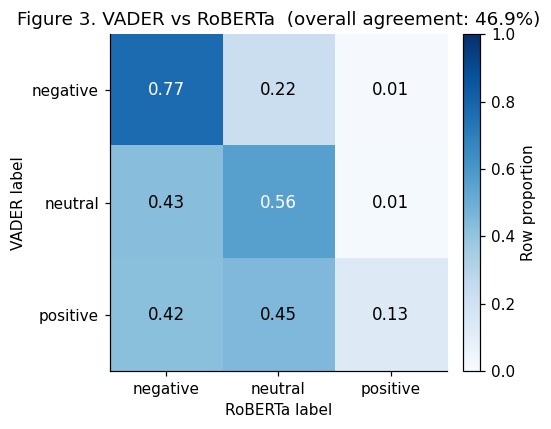

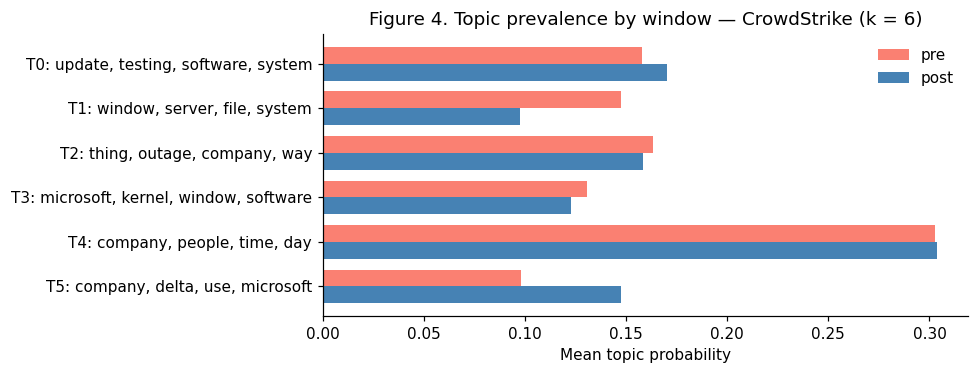

In [11]:
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 200
plt.rcParams['font.size'] = 10
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# --- Figure 1: comment volume over time ---
hours = (df['created_utc'] - T_APOLOGY) / 3600
fig, ax = plt.subplots(figsize=(8, 3.2))
ax.hist(hours, bins=80, color='steelblue', alpha=0.85, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='crimson', linestyle='--', linewidth=1.5, label='Apology issued (t=0)')
ax.set_xlabel('Hours from apology')
ax.set_ylabel('Number of comments')
ax.set_title(f'Figure 1. Comment volume over time — CrowdStrike (n = {len(df)})')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('/content/comment_volume_by_hour.png', bbox_inches='tight')
plt.show()

# --- Figure 2: sentiment pre vs post ---
fig, axes = plt.subplots(1, 2, figsize=(10, 3.3))
for ax, (var, label, p) in zip(axes, [('vader','VADER compound', p_v), ('roberta_signed','RoBERTa signed', p_r)]):
    pre  = df[df['window']=='pre'][var]
    post = df[df['window']=='post'][var]
    ax.hist(pre,  bins=30, alpha=0.6, color='salmon',
            label=f'pre  (n={len(pre)},  μ={pre.mean():+.2f})')
    ax.hist(post, bins=30, alpha=0.6, color='steelblue',
            label=f'post (n={len(post)}, μ={post.mean():+.2f})')
    ax.axvline(pre.mean(),  color='crimson',   linestyle='--', alpha=0.8, linewidth=1)
    ax.axvline(post.mean(), color='royalblue', linestyle='--', alpha=0.8, linewidth=1)
    ax.set_title(f'{label}  (Welch p = {p:.2e})')
    ax.set_xlabel('Score')
    ax.set_ylabel('Comments')
    ax.legend(fontsize=8, frameon=False)
plt.suptitle('Figure 2. Sentiment pre vs post apology — CrowdStrike', y=1.02)
plt.tight_layout()
plt.savefig('/content/sentiment_pre_post.png', bbox_inches='tight')
plt.show()

# --- Figure 3: VADER vs RoBERTa agreement ---
fig, ax = plt.subplots(figsize=(5, 4))
ct_norm = pd.crosstab(df['vader_label'], df['roberta_label'], normalize='index')
# Reorder for consistency
order = ['negative', 'neutral', 'positive']
ct_norm = ct_norm.reindex(index=order, columns=order, fill_value=0)
im = ax.imshow(ct_norm.values, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(order)
ax.set_yticks(range(3)); ax.set_yticklabels(order)
ax.set_xlabel('RoBERTa label')
ax.set_ylabel('VADER label')
ax.set_title(f'Figure 3. VADER vs RoBERTa  (overall agreement: {agreement_rate:.1%})')
for i in range(3):
    for j in range(3):
        v = ct_norm.values[i, j]
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color='white' if v > 0.5 else 'black', fontsize=11)
plt.colorbar(im, ax=ax, label='Row proportion', fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig('/content/vader_roberta_agreement.png', bbox_inches='tight')
plt.show()

# --- Figure 4: topic prevalence ---
topic_labels = [f'T{i}: {", ".join(w for w,p in lda.show_topic(i, 4))}' for i in range(best_k)]
fig, ax = plt.subplots(figsize=(9, 0.5 + 0.5 * best_k))
x = np.arange(best_k)
w = 0.38
ax.barh(x - w/2, prevalence.loc['pre'].values,  height=w, color='salmon',    label='pre')
ax.barh(x + w/2, prevalence.loc['post'].values, height=w, color='steelblue', label='post')
ax.set_yticks(x); ax.set_yticklabels(topic_labels)
ax.invert_yaxis()
ax.set_xlabel('Mean topic probability')
ax.set_title(f'Figure 4. Topic prevalence by window — CrowdStrike (k = {best_k})')
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig('/content/topic_prevalence_by_window.png', bbox_inches='tight')
plt.show()

## 11. Save outputs for the GitHub repo

In [12]:
# CSV — hashed and safe to commit
safe_cols = ['id','subreddit','author_hash','score','created_utc','window',
             'vader','vader_label','roberta_label','roberta_score','roberta_signed','body']
df[safe_cols].to_csv('/content/comments_hashed.csv', index=False)

# stats.json
stats_out = {
    'case': CASE,
    'collection': {
        't_crisis_utc':            T_CRISIS,
        't_apology_utc':           T_APOLOGY,
        'collection_window_start': T_AFTER,
        'collection_window_end':   T_BEFORE,
        'subreddits':              SUBREDDITS,
        'query':                   QUERY,
        'raw_comments':            len(all_raw),
        'after_filtering':         int(len(df)),
        'by_subreddit':            df['subreddit'].value_counts().to_dict(),
        'by_window':               df['window'].value_counts().to_dict(),
        'source':                  'PullPush.io API',
        'collected_at':            datetime.now(timezone.utc).isoformat(),
    },
    'sentiment': {
        'vader': {
            'pre':  {'mean': float(pre_v.mean()),  'std': float(pre_v.std()),  'n': int(len(pre_v))},
            'post': {'mean': float(post_v.mean()), 'std': float(post_v.std()), 'n': int(len(post_v))},
            'welch_t': float(t_v),
            'p_value': float(p_v),
            'shift':   float(post_v.mean() - pre_v.mean()),
        },
        'roberta': {
            'pre':  {'mean': float(pre_r.mean()),  'std': float(pre_r.std()),  'n': int(len(pre_r))},
            'post': {'mean': float(post_r.mean()), 'std': float(post_r.std()), 'n': int(len(post_r))},
            'welch_t': float(t_r),
            'p_value': float(p_r),
            'shift':   float(post_r.mean() - pre_r.mean()),
        },
        'agreement_rate': float(agreement_rate),
    },
    'topics': {
        'best_k': int(best_k),
        'coherence_scores': {int(k): float(v) for k, v in coh_scores.items()},
        'topic_words':      {int(i): [w for w, p in lda.show_topic(i, 15)] for i in range(best_k)},
        'prevalence_by_window': {win: {col: float(v) for col, v in row.items()}
                                  for win, row in prevalence.to_dict('index').items()},
    },
}

with open('/content/stats.json', 'w') as f:
    json.dump(stats_out, f, indent=2)

# Also save a copy of this notebook's key numbers for quick scan
print("="*60)
print("PILOT COMPLETE")
print("="*60)
print(f"Comments collected:     {len(all_raw)}")
print(f"After filtering:        {len(df)}")
print(f"  pre-apology:          {(df['window']=='pre').sum()}")
print(f"  post-apology:         {(df['window']=='post').sum()}")
print()
print(f"VADER sentiment shift:  {post_v.mean()-pre_v.mean():+.3f}  (p = {p_v:.2e})")
print(f"RoBERTa sentiment shift:{post_r.mean()-pre_r.mean():+.3f}  (p = {p_r:.2e})")
print(f"VADER–RoBERTa agreement:{agreement_rate:.1%}")
print(f"LDA topics:             k = {best_k}")
print()
print("Files saved to /content/:")
for f in ['comments_hashed.csv', 'stats.json',
          'comment_volume_by_hour.png', 'sentiment_pre_post.png',
          'vader_roberta_agreement.png', 'topic_prevalence_by_window.png']:
    path = f'/content/{f}'
    if os.path.exists(path):
        size = os.path.getsize(path)
        print(f"  ✓ {f}  ({size:,} bytes)")
    else:
        print(f"  ✗ {f}  MISSING")

PILOT COMPLETE
Comments collected:     3873
After filtering:        3768
  pre-apology:          379
  post-apology:         3389

VADER sentiment shift:  +0.057  (p = 2.71e-02)
RoBERTa sentiment shift:+0.072  (p = 3.86e-03)
VADER–RoBERTa agreement:46.9%
LDA topics:             k = 6

Files saved to /content/:
  ✓ comments_hashed.csv  (1,689,253 bytes)
  ✓ stats.json  (3,901 bytes)
  ✓ comment_volume_by_hour.png  (59,265 bytes)
  ✓ sentiment_pre_post.png  (99,449 bytes)
  ✓ vader_roberta_agreement.png  (73,143 bytes)
  ✓ topic_prevalence_by_window.png  (89,044 bytes)
